# Movie Data Analysis using TMDB 5000 Movies Dataset

## Subject:  Data Anslytic
## Lecturer: Heng  Sovanmonynuth

### Group Members
- Srors Muyyi
- Houn Sopheak
- Poeng Lyheng

---

### Project Objective

This project aims to apply the complete Data Science workflow using the TMDB 5000 Movies Dataset. The analysis includes data collection, data understanding, preprocessing, exploratory data analysis, feature engineering, visualization, insight generation, and predictive modeling to discover factors influencing movie performance and revenue.

## Dataset Information

**Dataset Name:** TMDB 5000 Movies Dataset

**Source:**
https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

**Why this dataset was selected**

This dataset was selected because it contains more than 4,803 movie records and multiple variables such as budget, revenue, popularity, genres, ratings, and release dates. It also contains missing values and requires preprocessing, making it suitable for applying the complete data science workflow from data cleaning to visualization and insight generation.

# **Step 2 Understand Explore**

In [ ]:
# Import Required Libraries


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load Dataset

df = pd.read_csv("tmdb_5000_movies.csv")


| Variable             | Description              |
| -------------------- | ------------------------ |
| budget               | Production budget (USD)  |
| revenue              | Box office revenue (USD) |
| popularity           | TMDB popularity score    |
| vote_average         | Average user rating      |
| vote_count           | Number of user votes     |
| genres               | Movie genres             |
| runtime              | Movie duration (minutes) |
| release_date         | Movie release date       |
| original_language    | Original language        |
| production_companies | Production companies     |


# **After loaded data now we are doing to observe our dataset**

In [ ]:
# Display the number of rows and columns

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 4803
Number of Columns : 20


In [ ]:
#Preview dataset, wanna see first rows, last and random records

df.head()
df.tail()
df.sample(5, random_state=42)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
596,70000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",NaN,8427,"[{""id"": 810, ""name"": ""budapest""}, {""id"": 1930,...",en,I Spy,"When the Switchblade, the most sophisticated p...",13.267631,"[{""name"": ""Columbia Pictures Corporation"", ""id...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2002-10-31,33561137,97.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Attitude meets espionage.,I Spy,5.2,269
3372,7,"[{""id"": 53, ""name"": ""Thriller""}, {""id"": 28, ""n...",NaN,13006,"[{""id"": 3528, ""name"": ""flooding""}, {""id"": 9685...",en,Split Second,"In a futuristic London, the rising sea levels ...",4.857028,"[{""name"": ""Entertainment"", ""id"": 7676}, {""name...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",1992-05-01,5,90.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,He's seen the future. Now he has to kill it.,Split Second,5.7,63
2702,14000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 9648, ""na...",NaN,18041,"[{""id"": 3616, ""name"": ""college""}, {""id"": 9937,...",en,Gossip,"On a beautiful college campus, something ugly ...",5.833687,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2000-04-21,5108820,90.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,"It can turn you on, or turn on you.",Gossip,5.5,68
2473,15000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",NaN,5038,"[{""id"": 107, ""name"": ""barcelona spain""}, {""id""...",en,Vicky Cristina Barcelona,Two girlfriends on a summer holiday in Spain b...,32.758254,"[{""name"": ""The Weinstein Company"", ""id"": 308},...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2008-08-15,96408652,96.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}, ...",Released,Life is the ultimate work of art,Vicky Cristina Barcelona,6.7,1020
8,250000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://harrypotter.warnerbros.com/harrypottera...,767,"[{""id"": 616, ""name"": ""witch""}, {""id"": 2343, ""n...",en,Harry Potter and the Half-Blood Prince,"As Harry begins his sixth year at Hogwarts, he...",98.885637,"[{""name"": ""Warner Bros."", ""id"": 6194}, {""name""...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2009-07-07,933959197,153.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Dark Secrets Revealed,Harry Potter and the Half-Blood Prince,7.4,5293


In [ ]:
#check column, wanna see culumn names

df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [ ]:
# check datatype

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [ ]:
# .T: rows become col, col become rows -> easy to read

df.describe().T

,count,mean,std,min,25%,50%,75%,max
budget,4803.0,2.904504e+07,4.072239e+07,0.0,790000.00000,1.500000e+07,4.000000e+07,3.800000e+08
id,4803.0,5.716548e+04,8.869461e+04,5.0,9014.50000,1.462900e+04,5.861050e+04,4.594880e+05
popularity,4803.0,2.149230e+01,3.181665e+01,0.0,4.66807,1.292159e+01,2.831350e+01,8.755813e+02
revenue,4803.0,8.226064e+07,1.628571e+08,0.0,0.00000,1.917000e+07,9.291719e+07,2.787965e+09
runtime,4801.0,1.068759e+02,2.261193e+01,0.0,94.00000,1.030000e+02,1.180000e+02,3.380000e+02
vote_average,4803.0,6.092172e+00,1.194612e+00,0.0,5.60000,6.200000e+00,6.800000e+00,1.000000e+01
vote_count,4803.0,6.902180e+02,1.234586e+03,0.0,54.00000,2.350000e+02,7.370000e+02,1.375200e+04


| Variable             | Description              |
| -------------------- | ------------------------ |
| budget               | Production budget (USD)  |
| revenue              | Box office revenue (USD) |
| popularity           | TMDB popularity score    |
| vote_average         | Average user rating      |
| vote_count           | Number of user votes     |
| genres               | Movie genres             |
| runtime              | Movie duration (minutes) |
| release_date         | Movie release date       |
| original_language    | Original language        |
| production_companies | Production companies     |


In [ ]:
# working on Numerical vs Categorical variables

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Variables:")
print(numerical_cols)

print("\nCategorical Variables:")
print(categorical_cols)

Numerical Variables:
['budget', 'id', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']

Categorical Variables:
['genres', 'homepage', 'keywords', 'original_language', 'original_title', 'overview', 'production_companies', 'production_countries', 'release_date', 'spoken_languages', 'status', 'tagline', 'title']


In [ ]:
# checking missing value

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
homepage,3091,64.36
tagline,844,17.57
overview,3,0.06
runtime,2,0.04
release_date,1,0.02


In [ ]:
# checking with duplicate records

duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [ ]:
# check unique values

df.nunique().sort_values()

,0
status,3
original_language,37
vote_average,71
runtime,156
budget,436
production_countries,469
spoken_languages,544
genres,1175
vote_count,1609
homepage,1691


# **Step 3 Data Cleaning & Preprocessing stage**

In [ ]:
# First we are going to make a copy of the original dataset because we wanna preserve it

df_clean = df.copy()

print("Working dataset created successfully.")

Working dataset created successfully.


In [ ]:
# Before going to cleaning stage i wanna check the missing values again, to make it easy for me to decide what to do next

missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage (%)": (df_clean.isnull().mean() * 100).round(2)
})

missing = missing[missing["Missing Values"] > 0]
missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage (%)
homepage,3091,64.36
tagline,844,17.57
overview,3,0.06
runtime,2,0.04
release_date,1,0.02


# **Since we don't have duplicate records imma move to datatype and double check it again**

In [ ]:
df_clean.dtypes

,0
budget,int64
genres,object
homepage,object
id,int64
keywords,object
original_language,object
original_title,object
overview,object
popularity,float64
production_companies,object


**As we can see the release_date is object (str/txt) so i am going to convert it to datetime so i can working with month/year**

In [ ]:
df_clean["release_date"] = pd.to_datetime(
    df_clean["release_date"],
    errors="coerce"
)

df_clean["release_date"].head()

,release_date
0,2009-12-10
1,2007-05-19
2,2015-10-26
3,2012-07-16
4,2012-03-07


In [ ]:
# checking missing value after convertion to make sure my convertion is correct.

df_clean["release_date"].isnull().sum()

np.int64(1)

In [ ]:
missing

,Missing Values,Percentage (%)
homepage,3091,64.36
overview,3,0.06
release_date,1,0.02
runtime,2,0.04
tagline,844,17.57


**Checking missing values in detail so i can decide to drop or keep**

**The homepage variable contains over 64% missing values. Since the majority of records lack this information and the column is not relevant to the objectives of this project, it was removed to simplify the dataset without affecting the analysis.**

In [ ]:
# Dripping homepage
df_clean = df_clean.drop(columns=["homepage"])
print("Dropped 'homepage'. Remaining columns:", df_clean.shape[1])

Dropped 'homepage'. Remaining columns: 19


**Fill tageline: not that the data is broken. Since it's a text field, we can't fill it with a mean/median like a number — instead we use a placeholder so it's clear the value is "not present" rather than accidentally blank/null in downstream steps.**

In [ ]:
df_clean["tagline"] = df_clean["tagline"].fillna("Not Available")
print(df_clean["tagline"].isnull().sum(), "missing values left in tagline")

0 missing values left in tagline


Drpping overview, runtime, and release_date: are all under 0.1% of the dataset — dropping them removes at most
3 rows out of 4,803. That's a rounding error, not a real data loss.
Filling them would actually be worse than dropping
- We can't guess a plot summary (`overview`) from nothing.
- We can't average a release date.
- Runtime could technically be filled with the median, but since these
are the same 2 obscure titles that are also missing an overview, it's
cleaner to just remove them once instead of patching each column separately.

In [ ]:
before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=["overview", "runtime", "release_date"])
after = df_clean.shape[0]

print(f"Rows before: {before}, Rows after: {after}, Rows dropped: {before - after}")

Rows before: 4803, Rows after: 4799, Rows dropped: 4


**Convert budget/revenue zeros into proper NaN**

**a value of 0 in these columns is not a real observation, it's a stand-in for "unknown." Leaving it as 0 would badly distort any calculation involving these columns (e.g. average revenue would look much lower than reality, and a revenue-prediction model would learn from thousands of fake data points).**

In [ ]:
df_clean["budget"] = df_clean["budget"].replace(0, np.nan)
df_clean["revenue"] = df_clean["revenue"].replace(0, np.nan)

print("Budget missing now:", df_clean["budget"].isnull().sum())
print("Revenue missing now:", df_clean["revenue"].isnull().sum())

Budget missing now: 1036
Revenue missing now: 1423


**Runtime = 0 is the same hidden-missing-value problem as budget/revenue**

Just like a $0 budget doesn't make sense, a movie can't actually run for
0 minutes. Checking the data shows 35 movies with `runtime == 0`,
separate from the 2 `NaN` rows we already dropped earlier. These are
almost certainly unreported runtimes, not real 0-minute films, so we
convert them to `NaN` the same way we did for budget and revenue —
marking them honestly as missing instead of pretending they're valid.

In [ ]:
# Runtime of 0 is not a real value — same pattern as budget/revenue
print("Runtime == 0 before:", (df_clean["runtime"] == 0).sum())

df_clean["runtime"] = df_clean["runtime"].replace(0, np.nan)

print("Runtime == 0 after:", (df_clean["runtime"] == 0).sum())
print("Runtime missing now:", df_clean["runtime"].isnull().sum())

Runtime == 0 before: 34
Runtime == 0 after: 0
Runtime missing now: 34


**Checking the `status` column before moving on**

The `status` column tells us whether a movie was actually released.
Checking the value counts shows the dataset is almost entirely
`Released` (4,795), with a small number of `Rumored` (5) and
`Post Production` (3) movies. These 8 movies were never fully released,
so their budget, revenue, and runtime numbers (even if present) don't
mean the same thing as a finished, released film — a "Rumored" movie's
budget/revenue is often just a placeholder or projection.

Since this analysis is about factors influencing movie performance and
revenue, we keep only `Released` movies going forward. This keeps our
numeric columns meaningful and comparable.

In [ ]:
# Check status distribution before deciding
print(df_clean["status"].value_counts())

# Keep only released movies — the rest have unreliable/placeholder data
before = df_clean.shape[0]
df_clean = df_clean[df_clean["status"] == "Released"]
after = df_clean.shape[0]

print(f"\nRows before: {before}, Rows after: {after}, Rows removed: {before - after}")

status
Released           4791
Rumored               5
Post Production       3
Name: count, dtype: int64

Rows before: 4799, Rows after: 4791, Rows removed: 8


**Checking for duplicate titles**

We already confirmed there are 0 duplicate `id` values, which is the
more reliable duplicate check since `id` is TMDB's unique identifier.
However, it's worth a quick look at duplicate `title` values too, in
case there are genuine data-entry errors. A duplicate title isn't
automatically a mistake though — it could be two different movies that
happen to share a name (remake), so this is just a sanity check,
not something we drop automatically.

In [ ]:
# Check duplicate titles (informational — not auto-dropped)
dup_titles = df_clean[df_clean["title"].duplicated(keep=False)].sort_values("title")
print(f"Number of duplicate title rows: {df_clean['title'].duplicated().sum()}")
dup_titles[["title", "release_date", "id"]]

Number of duplicate title rows: 3


,title,release_date,id
1359,Batman,1989-06-23,268
4267,Batman,1966-07-30,2661
3647,Out of the Blue,1980-05-01,39269
3693,Out of the Blue,2006-10-12,10844
972,The Host,2013-03-22,72710
2877,The Host,2006-07-27,1255


**confirm the cleaning worked**

In [ ]:
missing_final = pd.DataFrame({
"Missing Values": df_clean.isnull().sum(),
"Percentage (%)": (df_clean.isnull().mean() * 100).round(2)
})
missing_final = missing_final[missing_final["Missing Values"] > 0]
missing_final.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage (%)
revenue,1416,29.56
budget,1031,21.52
runtime,33,0.69


# **Parsing Nested JSON Columns**

Several columns (`genres`, `keywords`, `production_companies`,
`production_countries`, `spoken_languages`) look like lists of
dictionaries, but they're actually stored as plain text strings — this
is how TMDB exported the data. Right now pandas treats each of these as
one long string per row, not as a usable list of genres or companies.

Before EDA, we need to convert these strings into real Python lists, then
extract just the `name` field ("Action", "Adventure") from each one.
We use Python's built-in `ast.literal_eval`, which safely converts a
string that looks like Python code (a list of dicts) into an actual list
of dicts — safer than `eval()` since it only allows literal data, not
arbitrary code.

In [ ]:
import ast

def extract_names(json_str):
    """
    Converts a stringified list of dicts (e.g. '[{"id":28,"name":"Action"}]')
    into a comma-separated string of just the names (e.g. "Action, Adventure").
    Returns an empty string if the value is missing or can't be parsed.
    """
    try:
        items = ast.literal_eval(json_str)
        return ", ".join([item["name"] for item in items])
    except (ValueError, SyntaxError, TypeError):
        return ""

json_columns = ["genres", "keywords", "production_companies",
                 "production_countries", "spoken_languages"]

for col in json_columns:
    df_clean[col] = df_clean[col].apply(extract_names)

# Quick check that it worked
df_clean[json_columns].head()

,genres,keywords,production_companies,production_countries,spoken_languages
0,"Action, Adventure, Fantasy, Science Fiction","culture clash, future, space war, space colony...","Ingenious Film Partners, Twentieth Century Fox...","United States of America, United Kingdom","English, Español"
1,"Adventure, Fantasy, Action","ocean, drug abuse, exotic island, east india t...","Walt Disney Pictures, Jerry Bruckheimer Films,...",United States of America,English
2,"Action, Adventure, Crime","spy, based on novel, secret agent, sequel, mi6...","Columbia Pictures, Danjaq, B24","United Kingdom, United States of America","Français, English, Español, Italiano, Deutsch"
3,"Action, Crime, Drama, Thriller","dc comics, crime fighter, terrorist, secret id...","Legendary Pictures, Warner Bros., DC Entertain...",United States of America,English
4,"Action, Adventure, Science Fiction","based on novel, mars, medallion, space travel,...",Walt Disney Pictures,United States of America,English


**Why turn these into comma-separated strings instead of keeping them as lists?**

A comma-separated string (`"Action, Adventure, Fantasy"`) is easy to
read directly in the dataframe and easy to re-split later with
`.str.split(", ")` whenever we need the individual genres — for example,
when counting how many movies belong to each genre. Keeping the raw
Python list objects in the dataframe cells works too, but tends to cause
extra headaches when exporting to CSV or displaying the table, so the
string form is the more practical choice here.

In [ ]:
# Sanity check: genres should no longer look like raw JSON
print(df_clean["genres"].iloc[0])
print(df_clean["keywords"].iloc[0])

Action, Adventure, Fantasy, Science Fiction
culture clash, future, space war, space colony, society, space travel, futuristic, romance, space, alien, tribe, alien planet, cgi, marine, soldier, battle, love affair, anti war, power relations, mind and soul, 3d


# **Outlier Detection & Handling**

Outliers are values that sit far outside the typical range for a column
— they can be genuine (a real blockbuster with a huge budget) or errors
(a data-entry mistake). We check the four columns most likely to have
them: `budget`, `revenue`, `runtime`, and `vote_count`, since these are
the ones we're most likely to analyze and model later.

We use boxplots to see them visually, then the IQR (Interquartile Range)
method to count them precisely. IQR flags anything below
Q1 − 1.5×IQR or above Q3 + 1.5×IQR as an outlier — a standard,
widely-used rule of thumb.

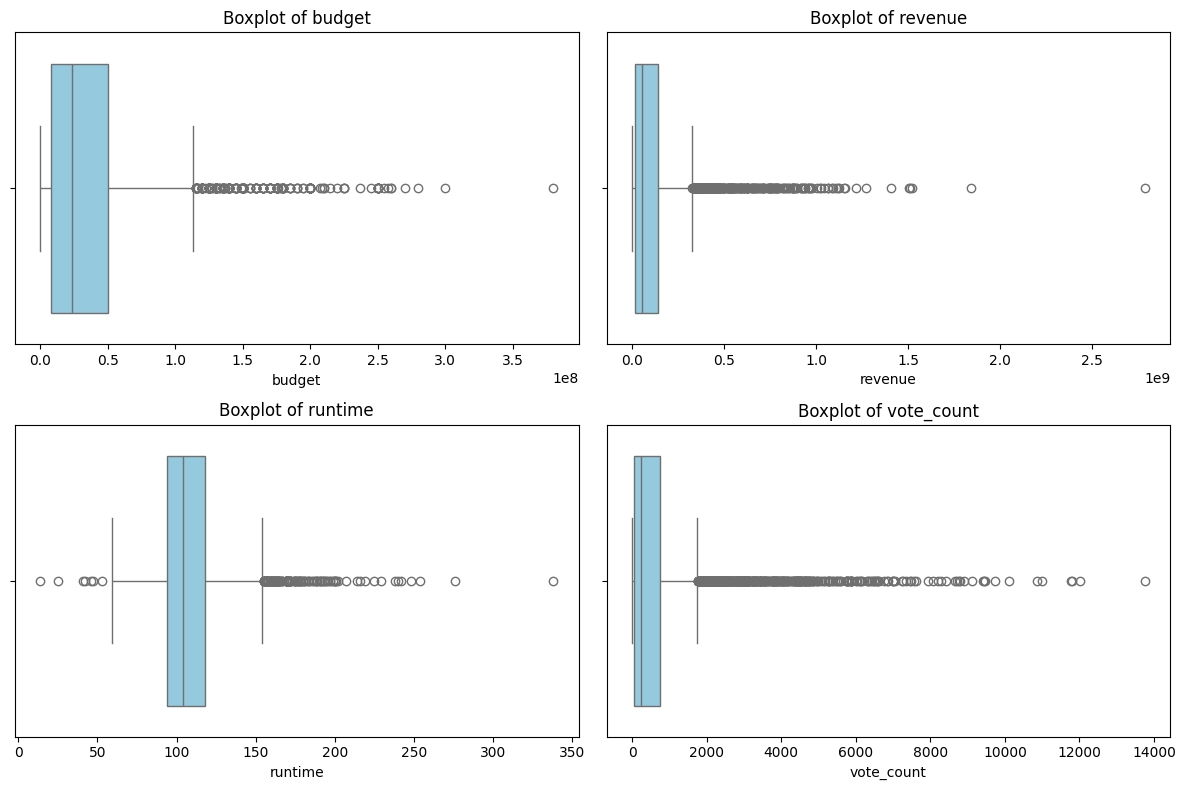

In [ ]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols_to_check = ["budget", "revenue", "runtime", "vote_count"]

for ax, col in zip(axes.flatten(), cols_to_check):
    sns.boxplot(x=df_clean[col], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [ ]:
# Count outliers using the IQR method
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

for col in cols_to_check:
    n_outliers = count_outliers_iqr(df_clean[col].dropna())
    pct = round(n_outliers / df_clean[col].dropna().shape[0] * 100, 2)
    print(f"{col}: {n_outliers} outliers ({pct}%)")

budget: 245 outliers (6.52%)
revenue: 299 outliers (8.86%)
runtime: 147 outliers (3.09%)
vote_count: 504 outliers (10.52%)


**Decision: keep the outliers, don't remove them**

Unlike a typical sensor-error dataset, high budget/revenue/vote_count
values in this dataset are almost always genuine — they represent real
blockbuster movies (e.g. Avatar, Avengers), not data entry errors. Same
with `runtime`: a very long runtime (like an epic historical film) is a
real movie, not a mistake.

Removing these rows would actually throw away some of the most
interesting cases for our analysis (what makes a blockbuster a
blockbuster?), and would bias any revenue-prediction model toward only
predicting for small/average movies. So the decision here is to **keep
all outliers**, but stay aware of them — for example, when we calculate
averages later, we may prefer median over mean for these columns since
the mean gets pulled heavily by these extreme values.

# **Encoding Categorical Variables**

The rubric requires converting categorical (text) variables into a
numeric form, since machine learning models can't work with raw text.

Looking at our categorical columns, `original_language` is the best
candidate: it's a genuine category (not free text like `overview`), and
it could plausibly relate to a movie's revenue or rating (e.g. English-
language films tend to have far wider international release).

However, it has 37 unique values, many with only a handful of movies.
One-hot encoding all 37 would create 37 new sparse columns, most of
which are almost entirely 0 — that adds noise more than signal. Instead,
we simplify it first: create a binary `is_english` feature (the
dominant category by far), then keep a numerically-encoded version of
the full column for cases where the detailed language might still matter.

In [ ]:
# Check the distribution first, to justify the simplification
print(df_clean["original_language"].value_counts().head(10))

original_language
en    4496
fr      70
es      32
zh      27
de      26
hi      19
ja      16
it      13
cn      12
ko      11
Name: count, dtype: int64


In [ ]:
# Step 1: Simple binary feature — is the movie in English or not?
df_clean["is_english"] = (df_clean["original_language"] == "en").astype(int)

# Step 2: Label-encode the full column too, in case we want the detail later
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean["original_language_encoded"] = le.fit_transform(df_clean["original_language"])

df_clean[["original_language", "is_english", "original_language_encoded"]].head()

,original_language,is_english,original_language_encoded
0,en,1,7
1,en,1,7
2,en,1,7
3,en,1,7
4,en,1,7


**Why not encode `status` the same way?**

We already filtered `status` down to only `"Released"` movies in an
earlier cleaning step, so it no longer varies — every row has the same
value. A column with only one unique value carries no information for a
model, so there's nothing to encode there; it's effectively a constant
now and can be safely ignored (or dropped) going forward.

# **Step4 EDA**

# Distributions of Key Numeric Variables

Before comparing variables to each other, we need to see
how each one is shaped on its own — is it symmetric, skewed, spread out,
clustered? This tells us whether a variable is safe to average, whether
it needs a log transform later, and whether "typical" movies dominate or
a few extreme ones do.

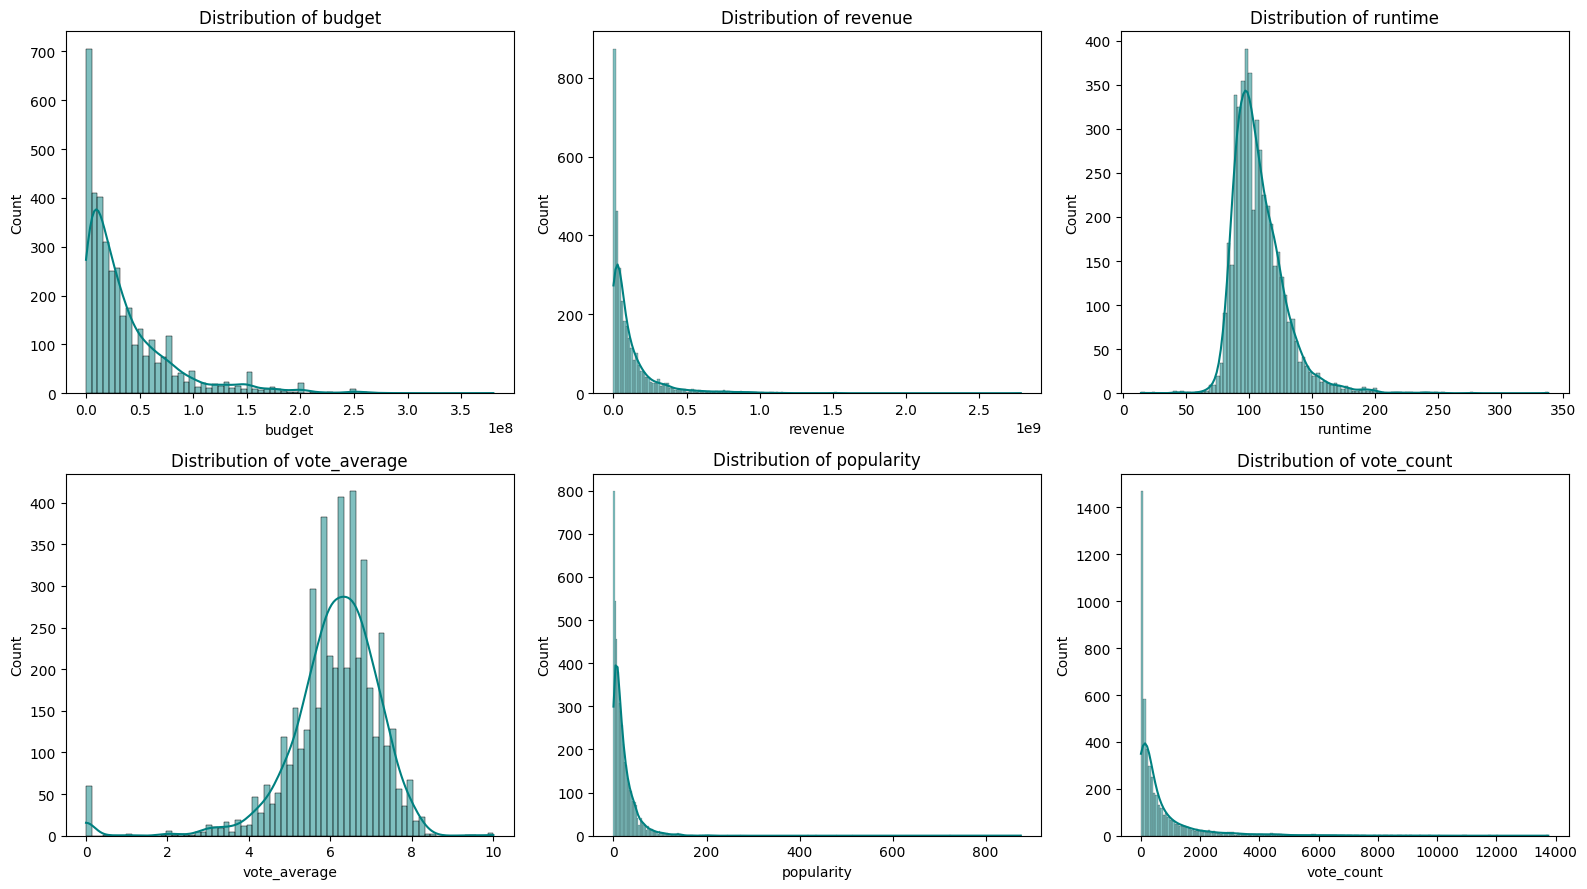

budget          2.22
revenue         3.88
runtime         1.82
vote_average   -1.95
popularity      9.72
vote_count      3.82
dtype: float64


In [ ]:
numeric_cols = ["budget", "revenue", "runtime", "vote_average", "popularity", "vote_count"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

print(df_clean[numeric_cols].skew().round(2))

Interpretation:
- `budget` (skew ≈ 2.22) and `revenue` (skew ≈ 3.88) are both heavily
right-skewed — most movies cluster at lower budgets/revenues, with a
long tail of blockbusters pulling the average up. This confirms what
we suspected during cleaning: the mean isn't a reliable "typical"
value for these two columns, median is more honest.
- `popularity` is extremely right-skewed (skew ≈ 9.72) — a very small
number of movies are dramatically more popular than the rest.
- `vote_average` is left-skewed (skew ≈ -1.95), meaning most movies
cluster around a decent rating (5–7), with fewer very low-rated films
dragging the tail down. This makes sense — very few movies get made
and released with critically terrible scores.
- `runtime` is closer to a normal distribution than the others, centered
around 100–110 minutes, which matches typical film-length conventions.

# **Correlation Matrix**

A correlation heatmap shows which numeric variables move
together. This directly matters for our project objective — discovering
what influences revenue — and it also flags redundant variables before
we build any prediction model later.

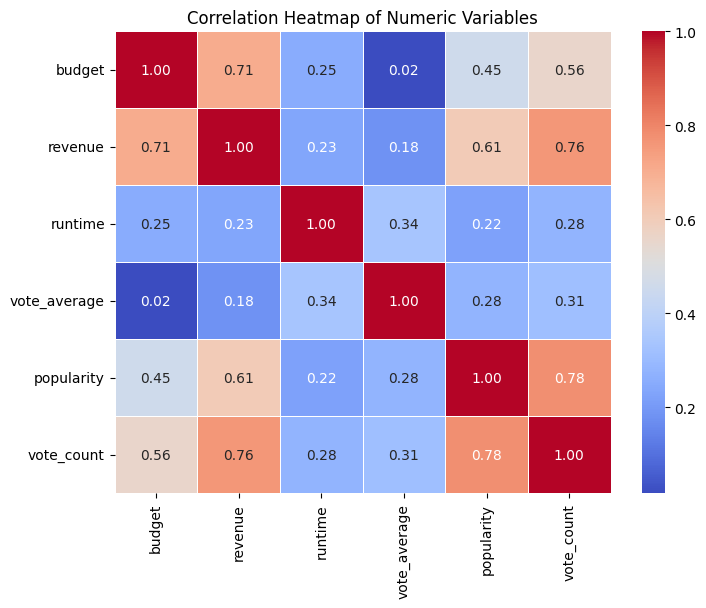

In [ ]:
plt.figure(figsize=(8, 6))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

**Interpretation:**

- `revenue` correlates most strongly with `vote_count` (0.76) and
`budget` (0.71) — bigger-budget movies earn more, and movies that earn
more also tend to get more people voting on them (wider audience reach).
- `popularity` and `vote_count` are strongly correlated (0.78) — this
makes sense, since both roughly capture how much attention a movie got.
- `vote_average` (the actual quality rating) barely correlates with
`budget` (0.02) — a notable finding: **spending more doesn't make a
movie rated better**, even though it clearly makes it earn more.
Budget predicts commercial success far better than critical reception.
- `runtime` has only weak correlations with everything (0.22–0.34) —
it's a relatively independent variable in this dataset.

# **Frequency Distribution: Most Common Genres**

genres currently holds multiple genres per movie in one
comma-separated string ("Action, Adventure"). To see which genres
are most common, we need to split each row into individual genres first,
then count how often each one appears across the whole dataset.

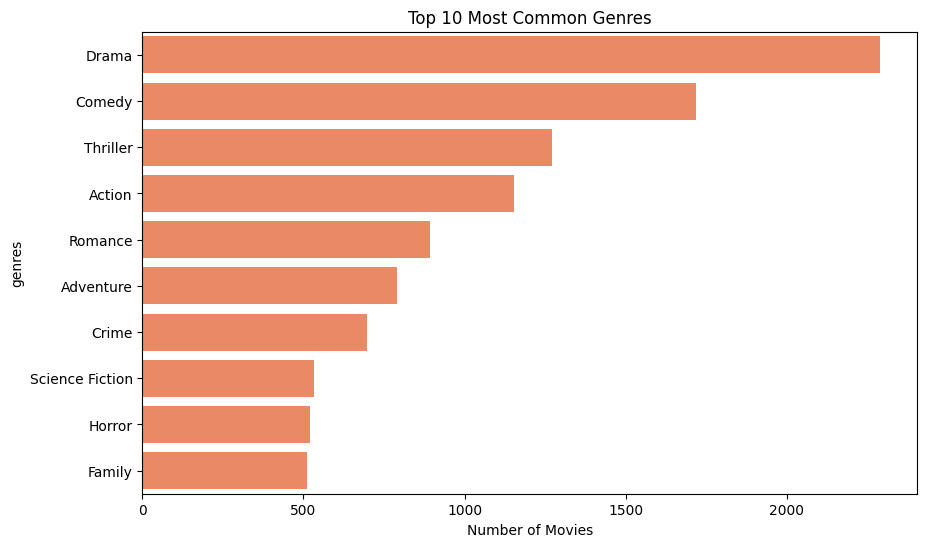

,count
genres,
Drama,2291
Comedy,1718
Thriller,1272
Action,1153
Romance,893
Adventure,790
Crime,696
Science Fiction,534
Horror,519


In [ ]:
# Split the comma-separated genres into individual entries, then count
genre_counts = df_clean["genres"].str.split(", ").explode()
genre_counts = genre_counts[genre_counts != ""].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.head(10).values, y=genre_counts.head(10).index, color="coral")
plt.title("Top 10 Most Common Genres")
plt.xlabel("Number of Movies")
plt.show()

genre_counts.head(10)

**Interpretation:**

Drama (2,291 movies) and Comedy (1,718) are by far the most common
genres in this dataset, followed by Thriller (1,272) and Action (1,153).
This is useful context for later steps — if we do genre-based revenue
comparisons, Drama and Comedy will have much larger sample sizes than
niche genres like Horror or Family, so any "average revenue per genre"
result needs to be read with that sample-size difference in mind.

# **Trend Over Time: Movies Released Per Year**

Plotting the number of movies released per year shows
whether film production has grown, and helps us judge whether older
movies (which may have less complete data) should be treated differently.

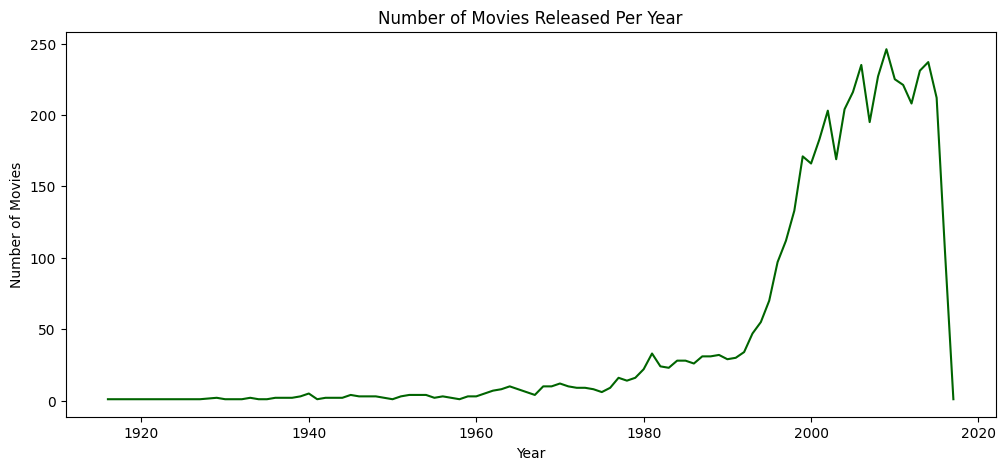

Earliest release year: 1916
Latest release year: 2017


In [ ]:
movies_per_year = df_clean["release_date"].dt.year.value_counts().sort_index()

plt.figure(figsize=(12, 5))
movies_per_year.plot(kind="line", color="darkgreen")
plt.title("Number of Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

print("Earliest release year:", df_clean['release_date'].dt.year.min())
print("Latest release year:", df_clean['release_date'].dt.year.max())

**Interpretation:**

The dataset spans 1916 to 2017, but the line shows a sharp upward trend
starting around the 1990s–2000s, with the number of movies released per
year growing dramatically in recent decades. This means our dataset is
heavily weighted toward modern films — worth mentioning as a limitation,
since conclusions about "typical" budget/revenue mostly reflect recent
movie-making economics, not the full history of film.

# **Group Analysis: Revenue and Budget by Genre**
So far we've looked at variables individually. Group
analysis asks a more useful question: does a movie's category (genre)
relate to how much it earns? This directly serves the project's goal of
understanding what influences movie performance.

We use **median** instead of mean here, deliberately. We already found
that `revenue` and `budget` are heavily right-skewed (skew ≈ 3.88 and
2.22), meaning a few blockbusters would drag a genre's *average* upward
and misrepresent what a "typical" movie in that genre actually earns.
Median is not affected by these extreme outliers, so it better reflects
the typical case.

Since a movie can belong to multiple genres at once ("Action,
Adventure"), we first split each movie's genre list into separate rows
— this is called "exploding" — so each genre gets fair credit rather
than genres only being counted when they happen to be first in the list.

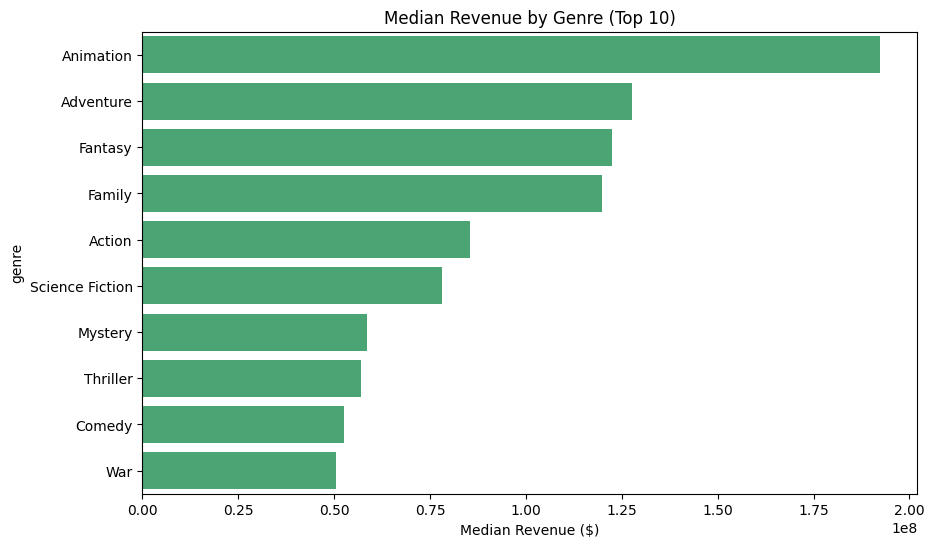

,revenue
genre,
Animation,192452832.0
Adventure,127600435.0
Fantasy,122489822.0
Family,119902599.5
Action,85490607.5
Science Fiction,78000000.0
Mystery,58690275.5
Thriller,57112106.5
Comedy,52502451.5


In [ ]:
# Split multi-genre movies into one row per genre, so each genre is counted fairly
exploded = df_clean.assign(genre=df_clean["genres"].str.split(", ")).explode("genre")
exploded = exploded[exploded["genre"] != ""]

genre_revenue = exploded.groupby("genre")["revenue"].median().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_revenue.head(10).values, y=genre_revenue.head(10).index, color="mediumseagreen")
plt.title("Median Revenue by Genre (Top 10)")
plt.xlabel("Median Revenue ($)")
plt.show()

genre_revenue.head(10)

**Interpretation:**

Animation ($192M median revenue), Adventure ($128M), Fantasy ($122M),
and Family ($120M) earn dramatically more than the dataset's most common
genre, Drama, which doesn't even appear in the top 10. This tells us
genre popularity (how many movies get made in it) and genre profitability
(how much it earns) are two different things — Drama is made the most
often, but it isn't where the money is.

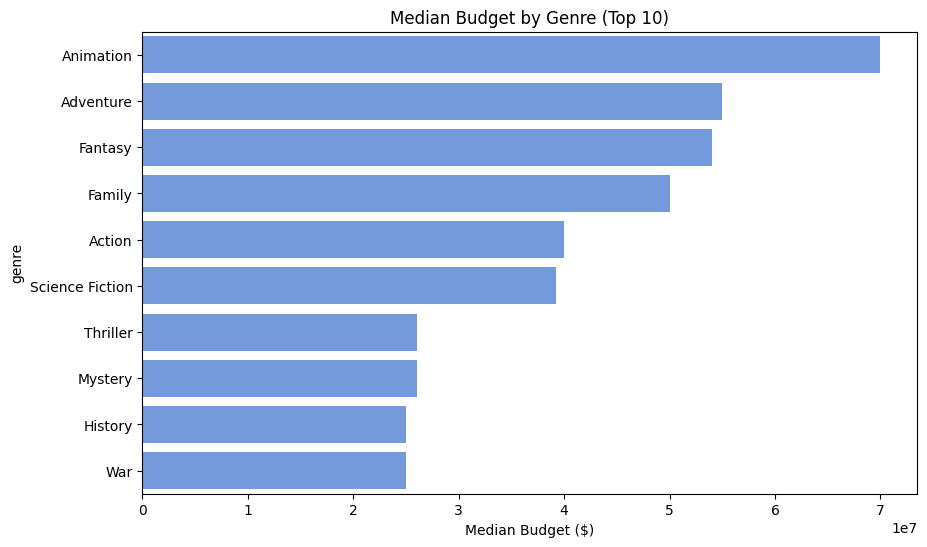

,budget
genre,
Animation,70000000.0
Adventure,55000000.0
Fantasy,54000000.0
Family,50000000.0
Action,40000000.0
Science Fiction,39200000.0
Thriller,26000000.0
Mystery,26000000.0
History,25000000.0


In [ ]:
genre_budget = exploded.groupby("genre")["budget"].median().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_budget.head(10).values, y=genre_budget.head(10).index, color="cornflowerblue")
plt.title("Median Budget by Genre (Top 10)")
plt.xlabel("Median Budget ($)")
plt.show()

genre_budget.head(10)

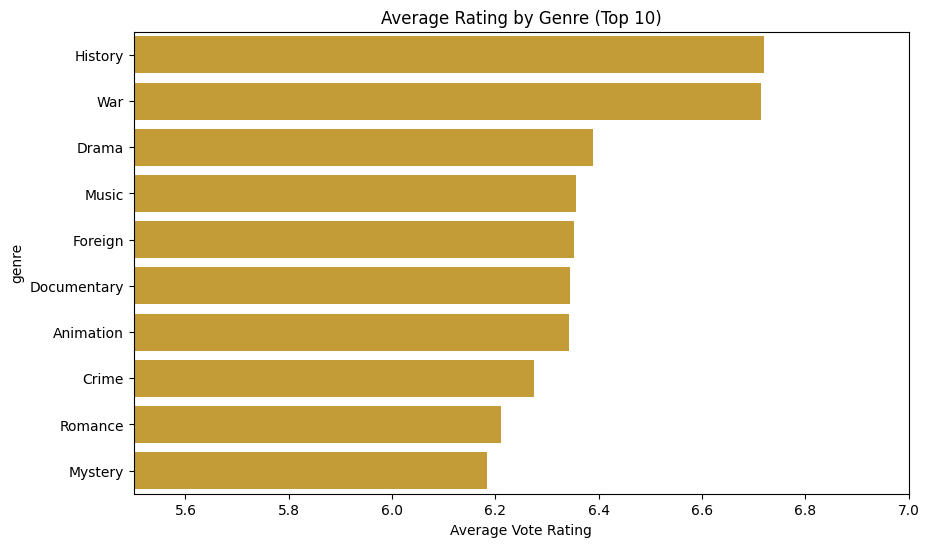

,vote_average
genre,
History,6.719797
War,6.713889
Drama,6.389699
Music,6.355676
Foreign,6.352941
Documentary,6.343925
Animation,6.341453
Crime,6.274138
Romance,6.209854


In [ ]:
genre_rating = exploded.groupby("genre")["vote_average"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_rating.head(10).values, y=genre_rating.head(10).index, color="goldenrod")
plt.title("Average Rating by Genre (Top 10)")
plt.xlabel("Average Vote Rating")
plt.xlim(5.5, 7)
plt.show()

genre_rating.head(10)

# **Group Analysis: Revenue and Budget Over Time (by Decade)**
Earlier we saw the number of movies released has grown
over time. Now we ask a different question: has the typical movie's
budget and revenue also grown, or just the volume of movies being made?
This requires extracting the decade from release_date, which is a
simple grouping step.

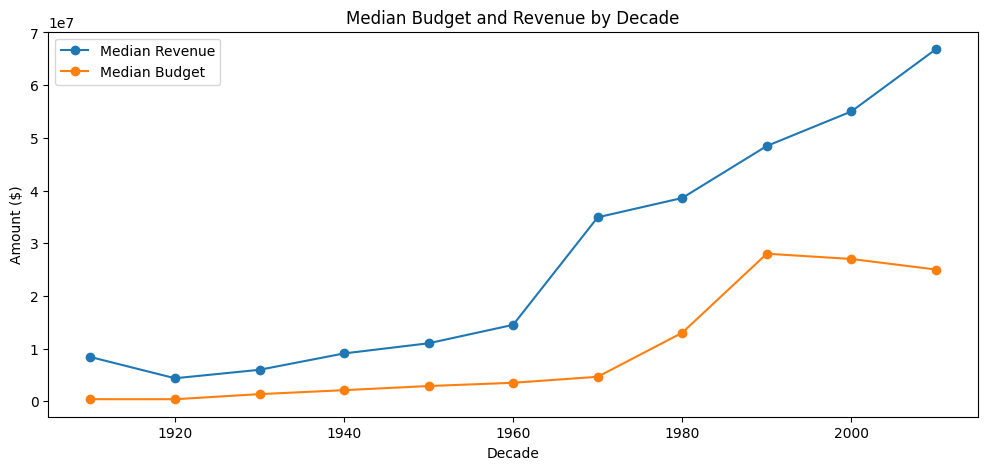

In [ ]:
# Group years into decades for a cleaner trend than year-by-year noise
df_clean["decade"] = (df_clean["release_date"].dt.year // 10) * 10

decade_revenue = df_clean.groupby("decade")["revenue"].median()
decade_budget = df_clean.groupby("decade")["budget"].median()

fig, ax = plt.subplots(figsize=(12, 5))
decade_revenue.plot(kind="line", marker="o", label="Median Revenue", ax=ax)
decade_budget.plot(kind="line", marker="o", label="Median Budget", ax=ax)
plt.title("Median Budget and Revenue by Decade")
plt.xlabel("Decade")
plt.ylabel("Amount ($)")
plt.legend()
plt.show()

**Interpretation:**

Both budget and revenue rise steadily decade over decade — median
revenue grew from about $4.4M in the 1920s to $66.8M in the 2010s, and
median budget rose from roughly $2.1M in the 1940s to $28M by the 1990s
before leveling off around $25–27M in the 2000s–2010s. The leveling-off
in budget while revenue kept climbing suggests recent decades have
gotten more efficient at generating revenue per dollar spent — possibly
due to global distribution, streaming, and international box office
growth, rather than just spending more on production.

# **Step 5 : Feature Engineering**

1. `profit` — from `revenue` and `budget`
2. `release_year` / `release_month` — from `release_date`
3. `budget_tier` — a binned category from `budget`

In [ ]:
df_clean["profit"] = df_clean["revenue"] - df_clean["budget"]

print(df_clean["profit"].describe())
print("\nMissing profit values (movies missing budget or revenue):", df_clean["profit"].isnull().sum())

count    3.228000e+03
mean     8.061384e+07
std      1.581659e+08
min     -1.657101e+08
25%      2.355852e+05
50%      2.617376e+07
75%      9.749217e+07
max      2.550965e+09
Name: profit, dtype: float64

Missing profit values (movies missing budget or revenue): 1563


revenue alone doesn't tell us whether a movie
was actually a financial success — a movie that earned $100M but cost
$150M to make lost money, while a $100M movie that cost $5M was a huge
win. Right now we have both numbers separately, but nothing that
directly answers "did this movie make money, and how much?" profit
answers that in one column.

# **Feature 2: Release Year and Release Month**

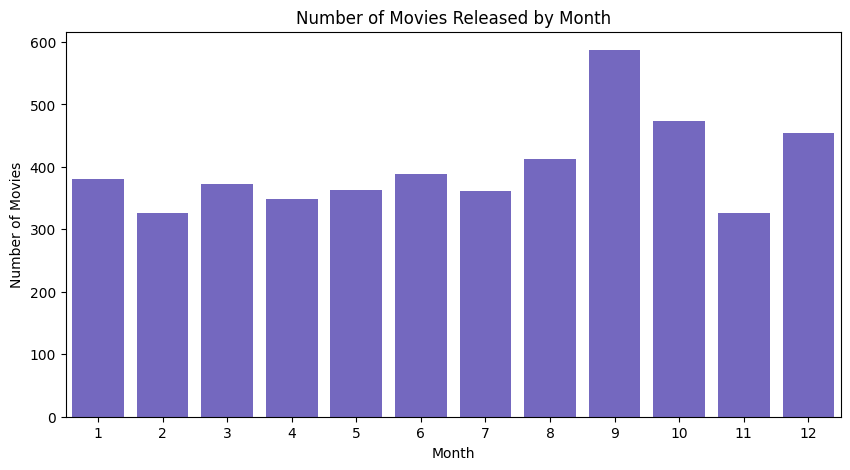

In [ ]:
df_clean["release_year"] = df_clean["release_date"].dt.year
df_clean["release_month"] = df_clean["release_date"].dt.month

movies_by_month = df_clean["release_month"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=movies_by_month.index, y=movies_by_month.values, color="slateblue")
plt.title("Number of Movies Released by Month")
plt.xlabel("Month")
plt.ylabel("Number of Movies")
plt.show()

release_date is a full date, which is too
specific to group or compare movies by. Nobody analyzes "movies released
on July 4th" as a category — but "movies released in 2010" or "movies
released in summer" are genuinely meaningful groupings. Splitting the
date into release_year and release_month lets us reuse the decade
analysis we already did more precisely, and opens up a new question:
does the month a movie comes out matter (e.g. summer blockbuster
season vs. a quiet January release)?

# **Feature 3: Budget Tier (Binning)**

In [ ]:
bins = [0, 5_000_000, 20_000_000, 60_000_000, np.inf]
labels = ["Low", "Medium", "High", "Blockbuster"]

df_clean["budget_tier"] = pd.cut(df_clean["budget"], bins=bins, labels=labels)

df_clean["budget_tier"].value_counts()

,count
budget_tier,
High,1252
Medium,1104
Low,704
Blockbuster,700


`budget` is a continuous number spanning from a
few thousand dollars to hundreds of millions — too fine-grained for
some kinds of comparison ("how does an average low-budget indie
film compare to a blockbuster?"). Binning groups movies into a small
number of meaningful categories, making group comparisons (like the
genre analysis we did earlier) easier to read and present.

We chose the cutoffs based on the actual budget distribution rather than
arbitrary round numbers — the 25th/50th/75th percentiles of `budget` are
roughly $8M / $23M / $50M, so the bin edges below roughly track those
natural breakpoints, adjusted slightly to make the labels intuitive
(Low / Medium / High / Blockbuster).

# **Step6 : Data Visulization**

### Box Plot: Rating and Revenue by Budget Tier

**Purpose:** A box plot shows the spread and median of a numeric
variable across categories in one view — better than a single bar,
since it also reveals variation within each group, not just its
average. We use our engineered `budget_tier` feature to see whether
spending more actually buys a better-rated or higher-earning movie, or
just a wider range of outcomes.

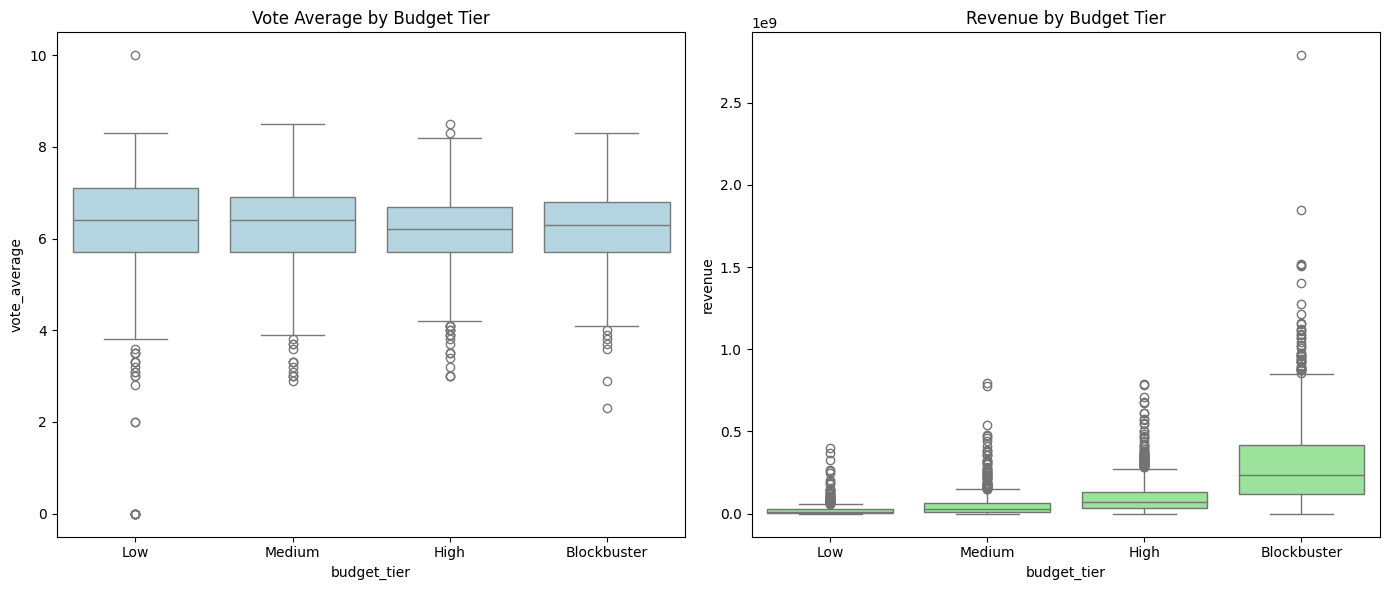

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_clean, x="budget_tier", y="vote_average",
            order=["Low", "Medium", "High", "Blockbuster"], ax=axes[0], color="lightblue")
axes[0].set_title("Vote Average by Budget Tier")

sns.boxplot(data=df_clean, x="budget_tier", y="revenue",
            order=["Low", "Medium", "High", "Blockbuster"], ax=axes[1], color="lightgreen")
axes[1].set_title("Revenue by Budget Tier")

plt.tight_layout()
plt.show()

**Interpretation:** Median `vote_average` is nearly flat across all four
tiers (6.2–6.4) — a bigger budget clearly does not buy a better rating,
confirming what we found earlier with the near-zero budget–rating
correlation. Median `revenue`, on the other hand, climbs sharply with
budget tier: from about $8.6M (Low) to $232.6M (Blockbuster) — roughly a
27x jump. This box plot makes the earlier correlation finding much more
concrete: budget buys revenue, not quality.

### Pair Plot: Relationships Between Numeric Variables

**Purpose:** A pair plot shows every numeric variable plotted against
every other one, all at once — useful for spotting relationships (or
lack of them) we might not have thought to check individually, beyond
what the correlation heatmap's single numbers can show.

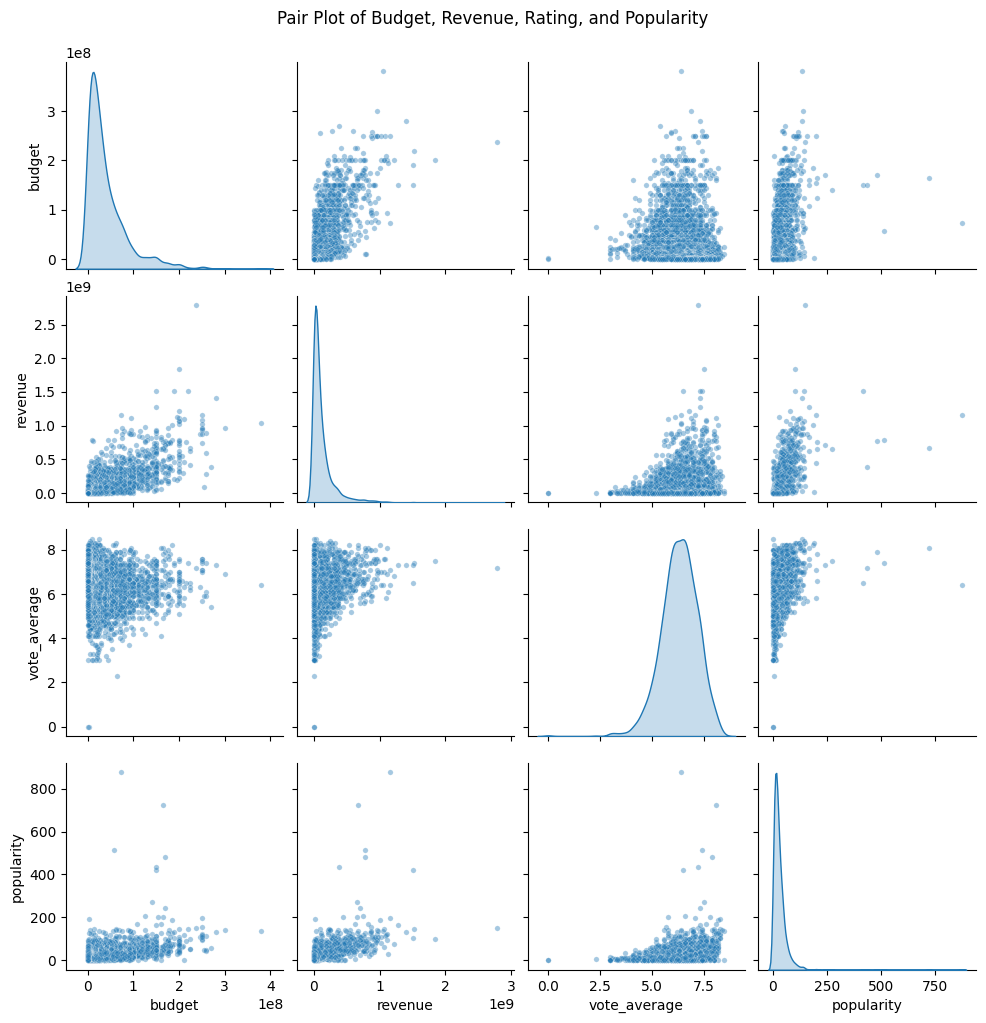

In [ ]:
pairplot_cols = ["budget", "revenue", "vote_average", "popularity"]

sns.pairplot(df_clean[pairplot_cols].dropna(), diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pair Plot of Budget, Revenue, Rating, and Popularity", y=1.02)
plt.show()

**Interpretation:** The budget–revenue panel shows a clear upward,
fan-shaped pattern (variance grows as budget grows) — consistent with
their 0.71 correlation. The vote_average panels against budget and
revenue look like a flat, shapeless cloud, visually confirming there's
no meaningful relationship there. The diagonal KDE plots also make the
skew we found earlier visible directly: budget and revenue both pile up
near zero with a long thin tail to the right.

### Pie Chart: Genre Share

**Purpose:** A pie chart is best for showing simple part-to-whole
proportions — here, what share of all genre tags in the dataset belong
to each major genre. We group the smaller genres into "Other" so the
chart stays readable instead of splitting into 20 tiny slices.

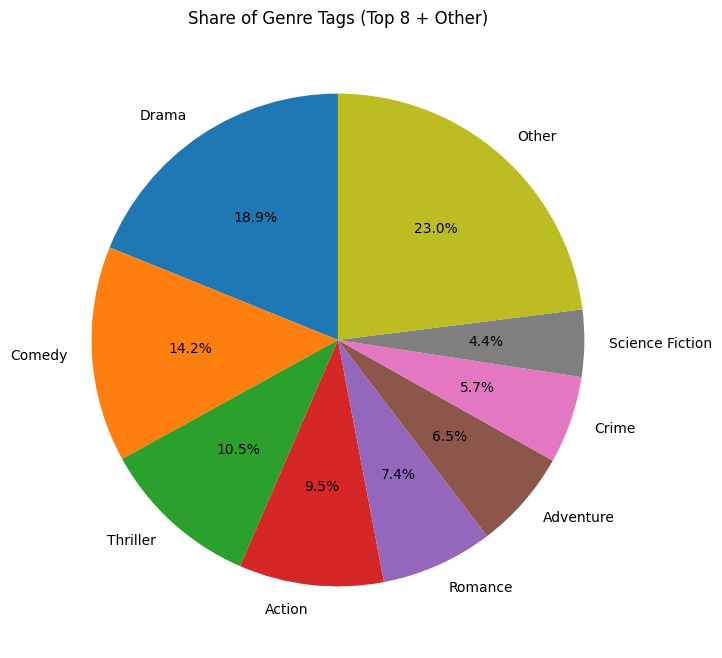

In [ ]:
genre_counts = df_clean["genres"].str.split(", ").explode()
genre_counts = genre_counts[genre_counts != ""].value_counts()

top8 = genre_counts.head(8)
other_total = genre_counts.iloc[8:].sum()
pie_data = pd.concat([top8, pd.Series({"Other": other_total})])

plt.figure(figsize=(8, 8))
plt.pie(pie_data, labels=pie_data.index, autopct="%1.1f%%", startangle=90)
plt.title("Share of Genre Tags (Top 8 + Other)")
plt.show()

**Interpretation:** Drama accounts for about 18.9% of all genre tags,
the single largest slice, with Comedy next at 14.2%. The "Other"
category (all genres outside the top 8, like Horror, Family, Mystery)
still makes up about 23% combined — so while Drama and Comedy dominate
individually, more than a fifth of all genre assignments come from the
long tail of smaller genres.

### Scatter Plot: Budget vs. Revenue

**Purpose:** A scatter plot shows the raw relationship between two
continuous variables at the individual movie level, which is more
precise than a box plot's grouped summary. We plot `budget` against
`revenue`, coloring points by `budget_tier` to connect this chart back
to the categories we engineered.

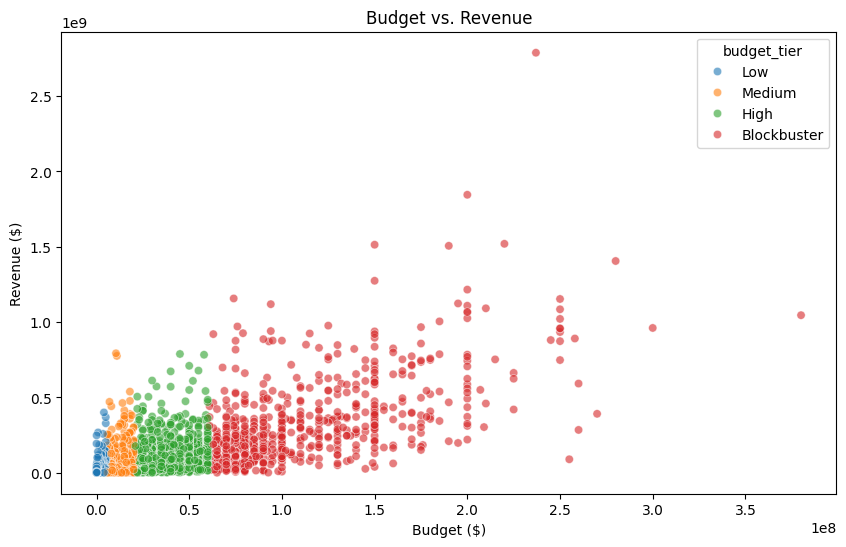

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="budget", y="revenue", hue="budget_tier",
                 hue_order=["Low", "Medium", "High", "Blockbuster"], alpha=0.6)
plt.title("Budget vs. Revenue")
plt.xlabel("Budget ($)")
plt.ylabel("Revenue ($)")
plt.show()

**Interpretation:** There's a visible upward trend (correlation ≈ 0.71),
but it's far from a straight line — many Low and Medium budget movies
still scatter well above the general trend line, meaning some smaller-
budget films substantially outperform their spending, while several
Blockbuster-tier movies underperform relative to their huge budgets.
Budget raises the *ceiling* and the *typical outcome*, but it clearly
doesn't guarantee a hit.

# **Step 9: Prediction Model (Bonus)**

## Objective

The objective of this section is to predict movie box-office revenue using selected movie characteristics.

Two regression models are evaluated:

1. Linear Regression
2. Random Forest Regression

The models are compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

# Step 9.1: Import the required libraries

In [ ]:
# Libraries required for the prediction model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("ML libraries imported successfully.")

ML libraries imported successfully.


# Step 9.2: Select the target and input featuresa

## Feature Selection

The target variable is:

- `revenue`: Total box-office revenue generated by the movie.

The selected input features are:

- `budget`: Production budget.
- `runtime`: Movie duration in minutes.
- `popularity`: TMDB popularity score.
- `vote_count`: Number of audience votes.
- `vote_average`: Average audience rating.
- `release_year`: Year in which the movie was released.
- `is_english`: Whether the movie's original language is English.

In [ ]:
# Select the features used to predict movie revenue

features = [
    "budget",
    "runtime",
    "popularity",
    "vote_count",
    "vote_average",
    "release_year",
    "is_english"
]

target = "revenue"

# Create a separate modeling dataset
model_df = df_clean[features + [target]].copy()

print("Selected features:")
print(features)

print("\nTarget variable:")
print(target)

print("\nInitial modeling dataset shape:", model_df.shape)

model_df.head()

Selected features:
['budget', 'runtime', 'popularity', 'vote_count', 'vote_average', 'release_year', 'is_english']

Target variable:
revenue

Initial modeling dataset shape: (4791, 8)


,budget,runtime,popularity,vote_count,vote_average,release_year,is_english,revenue
0,237000000.0,162.0,150.437577,11800,7.2,2009,1,2.787965e+09
1,300000000.0,169.0,139.082615,4500,6.9,2007,1,9.610000e+08
2,245000000.0,148.0,107.376788,4466,6.3,2015,1,8.806746e+08
3,250000000.0,165.0,112.312950,9106,7.6,2012,1,1.084939e+09
4,260000000.0,132.0,43.926995,2124,6.1,2012,1,2.841391e+08


# Step 9.3: Check missing values

In [ ]:
# Check missing values in the modeling dataset

missing_model = pd.DataFrame({
    "Missing Values": model_df.isnull().sum(),
    "Percentage (%)": (model_df.isnull().mean() * 100).round(2)
})

missing_model

,Missing Values,Percentage (%)
budget,1031,21.52
runtime,33,0.69
popularity,0,0.00
vote_count,0,0.00
vote_average,0,0.00
release_year,0,0.00
is_english,0,0.00
revenue,1416,29.56


# Step 9.4: Remove rows that cannot be used for modeling

In [ ]:
# Remove rows with missing values in the selected features or target

rows_before = model_df.shape[0]

model_df = model_df.dropna()

rows_after = model_df.shape[0]

print("Rows before removing missing values:", rows_before)
print("Rows after removing missing values :", rows_after)
print("Rows removed                      :", rows_before - rows_after)

print("\nRemaining missing values:")
print(model_df.isnull().sum())

Rows before removing missing values: 4791
Rows after removing missing values : 3228
Rows removed                      : 1563

Remaining missing values:
budget          0
runtime         0
popularity      0
vote_count      0
vote_average    0
release_year    0
is_english      0
revenue         0
dtype: int64


# Step 9.5: Check the cleaned model dataset

In [ ]:
# Check the cleaned modeling dataset

print("Final modeling dataset shape:", model_df.shape)

model_df.describe().T

Final modeling dataset shape: (3228, 8)


,count,mean,std,min,25%,50%,75%,max
budget,3228.0,4.066642e+07,4.439840e+07,1.000000,1.050000e+07,2.500000e+07,5.500000e+07,3.800000e+08
runtime,3228.0,1.107249e+02,2.096892e+01,41.000000,9.600000e+01,1.070000e+02,1.210000e+02,3.380000e+02
popularity,3228.0,2.904216e+01,3.616813e+01,0.019984,1.046821e+01,2.041296e+01,3.734075e+01,8.755813e+02
vote_count,3228.0,9.775858e+02,1.414427e+03,0.000000,1.780000e+02,4.710000e+02,1.148000e+03,1.375200e+04
vote_average,3228.0,6.309665e+00,8.738459e-01,0.000000,5.800000e+00,6.300000e+00,6.900000e+00,8.500000e+00
release_year,3228.0,2.001678e+03,1.328057e+01,1916.000000,1.998000e+03,2.005000e+03,2.010000e+03,2.016000e+03
is_english,3228.0,9.606568e-01,1.944404e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
revenue,3228.0,1.212803e+08,1.863197e+08,5.000000,1.700000e+07,5.519150e+07,1.463434e+08,2.787965e+09


# Step 9.6: Define X and y

In [ ]:
# Define input features and target variable

X = model_df[features]
y = model_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (3228, 7)
y shape: (3228,)


,budget,runtime,popularity,vote_count,vote_average,release_year,is_english
0,237000000.0,162.0,150.437577,11800,7.2,2009,1
1,300000000.0,169.0,139.082615,4500,6.9,2007,1
2,245000000.0,148.0,107.376788,4466,6.3,2015,1
3,250000000.0,165.0,112.312950,9106,7.6,2012,1
4,260000000.0,132.0,43.926995,2124,6.1,2012,1


# Step 9.7: Split the data into training and testing sets

In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)
print("Training target shape :", y_train.shape)
print("Testing target shape  :", y_test.shape)

Training feature shape: (2582, 7)
Testing feature shape : (646, 7)
Training target shape : (2582,)
Testing target shape  : (646,)


The dataset was divided into an 80% training set and a 20% testing set. The training set was used to teach the models, while the testing set was kept unseen during training and used to evaluate how well the models perform on new data. A random_state of 42 was used to make the results reproducible.

# Step 9.8: Create an evaluation function

In [ ]:
# Function for evaluating regression models

def evaluate_regression_model(model_name, actual, predicted):
    """
    Calculate and display common regression evaluation metrics.
    """

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    print(f"{model_name} Evaluation")
    print("-" * 40)
    print(f"MAE  : ${mae:,.2f}")
    print(f"RMSE : ${rmse:,.2f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

### Evaluation Metrics

**Mean Absolute Error (MAE)**  
The average absolute difference between actual and predicted revenue. A lower MAE is better.

**Root Mean Squared Error (RMSE)**  
Measures prediction errors while giving greater penalties to very large errors. A lower RMSE is better.

**R² Score**  
Shows how much of the variation in movie revenue is explained by the model.

- R² close to 1 indicates strong predictive performance.
- R² close to 0 indicates weak predictive performance.
- A negative R² indicates that the model performs worse than simply predicting the average revenue.

# Step 9.9: Build the Linear Regression model

In [ ]:
# Create and train the Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# Predict revenue for the testing data

linear_predictions = linear_model.predict(X_test)

linear_predictions[:10]

array([ 1.55536360e+08,  7.52666472e+07,  1.70481058e+08,  4.28763533e+07,
        3.14205780e+07, -3.03723135e+06,  4.15228956e+08,  1.06344388e+09,
        2.51716832e+08,  3.80225340e+07])

In [ ]:
# Evaluate Linear Regression

linear_results = evaluate_regression_model(
    model_name="Linear Regression",
    actual=y_test,
    predicted=linear_predictions
)

Linear Regression Evaluation
----------------------------------------
MAE  : $65,518,113.48
RMSE : $130,830,732.62
R²   : 0.6603


# Step 9.10: Inspect the Linear Regression coefficients

In [ ]:
# Examine the coefficients learned by Linear Regression

linear_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

linear_coefficients["Absolute Coefficient"] = (
    linear_coefficients["Coefficient"].abs()
)

linear_coefficients = linear_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

linear_coefficients

,Feature,Coefficient,Absolute Coefficient
4,vote_average,-3.144930e+06,3.144930e+06
6,is_english,-1.701895e+06,1.701895e+06
5,release_year,-9.096934e+05,9.096934e+05
2,popularity,4.722022e+05,4.722022e+05
1,runtime,-1.858986e+05,1.858986e+05
3,vote_count,5.962872e+04,5.962872e+04
0,budget,1.743663e+00,1.743663e+00


The coefficients indicate the direction of each feature’s relationship with predicted revenue. However, direct comparison of coefficient sizes is difficult because the features use different measurement scales.

# Step 9.11: Build the Random Forest model

In [ ]:
# Create the Random Forest Regression model

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**Parameter explanation**

- n_estimators=300: builds 300 decision trees.
- min_samples_split=5: requires at least five observations before splitting a node.
- min_samples_leaf=2: prevents extremely small leaf groups.
- random_state=42: gives reproducible results.
- n_jobs=-1: uses all available processor cores.

# Step 9.12: Predict using Random Forest

In [ ]:
# Predict revenue using Random Forest

random_forest_predictions = random_forest_model.predict(X_test)

random_forest_predictions[:10]

array([1.24693532e+08, 6.72421344e+07, 1.51002574e+08, 1.05657495e+07,
       5.01727436e+07, 3.72793101e+07, 4.13489769e+08, 7.30752530e+08,
       1.80594331e+08, 3.08095149e+07])

In [ ]:
# Evaluate Random Forest Regression

random_forest_results = evaluate_regression_model(
    model_name="Random Forest Regression",
    actual=y_test,
    predicted=random_forest_predictions
)

Random Forest Regression Evaluation
----------------------------------------
MAE  : $56,837,132.66
RMSE : $119,274,774.78
R²   : 0.7177


# Step 9.13: Compare the models

In [ ]:
# Combine model results into one comparison table (Compare the Models)

model_comparison = pd.DataFrame([
    linear_results,
    random_forest_results
])

model_comparison = model_comparison.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,MAE,RMSE,R²
0,Random Forest Regression,5.683713e+07,1.192748e+08,0.717670
1,Linear Regression,6.551811e+07,1.308307e+08,0.660313


In [ ]:
# Create a presentation-friendly result table

model_comparison_display = model_comparison.copy()

model_comparison_display["MAE"] = model_comparison_display["MAE"].map(
    lambda value: f"${value:,.2f}"
)

model_comparison_display["RMSE"] = model_comparison_display["RMSE"].map(
    lambda value: f"${value:,.2f}"
)

model_comparison_display["R²"] = model_comparison_display["R²"].round(4)

model_comparison_display

,Model,MAE,RMSE,R²
0,Random Forest Regression,"$56,837,132.66","$119,274,774.78",0.7177
1,Linear Regression,"$65,518,113.48","$130,830,732.62",0.6603


# Step 9.14: Automatically select the better model

In [ ]:
# Identify the model with the highest R² score

best_model_name = model_comparison.iloc[0]["Model"]
best_r2 = model_comparison.iloc[0]["R²"]
best_mae = model_comparison.iloc[0]["MAE"]
best_rmse = model_comparison.iloc[0]["RMSE"]

print("Best-performing model:", best_model_name)
print(f"R² score: {best_r2:.4f}")
print(f"MAE: ${best_mae:,.2f}")
print(f"RMSE: ${best_rmse:,.2f}")

Best-performing model: Random Forest Regression
R² score: 0.7177
MAE: $56,837,132.66
RMSE: $119,274,774.78


# Step 9.15: Visualize model performance

**A. Compare R² scores**

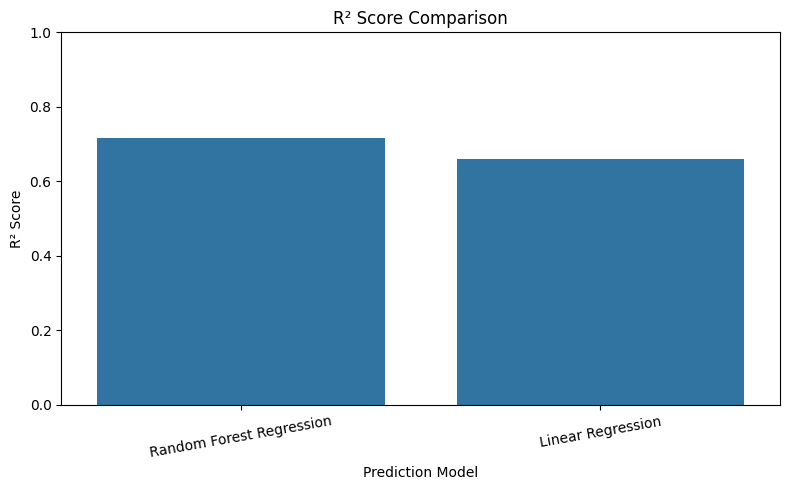

In [ ]:
# Compare R² scores

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="R²"
)

plt.title("R² Score Comparison")
plt.xlabel("Prediction Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**B. Compare prediction errors**

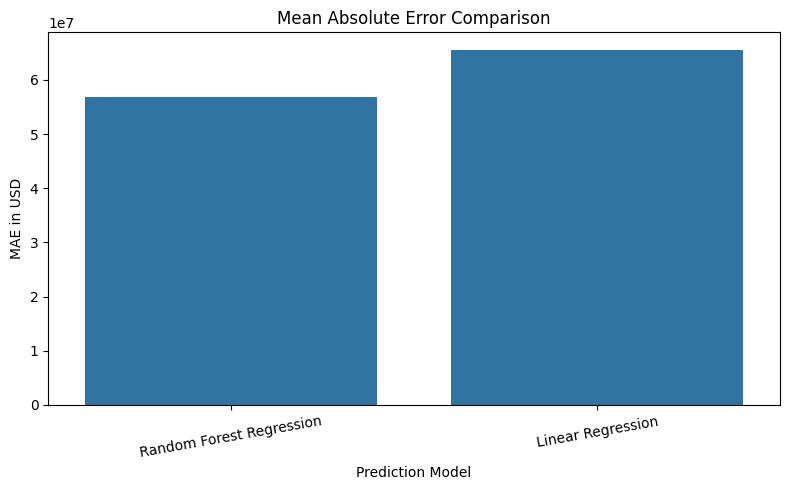

In [ ]:
# Compare MAE values

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="MAE"
)

plt.title("Mean Absolute Error Comparison")
plt.xlabel("Prediction Model")
plt.ylabel("MAE in USD")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Step 9.16: Actual revenue versus predicted revenue

In [ ]:
# Select predictions from the better-performing model

if random_forest_results["R²"] >= linear_results["R²"]:
    best_predictions = random_forest_predictions
    selected_model = random_forest_model
    selected_model_name = "Random Forest Regression"
else:
    best_predictions = linear_predictions
    selected_model = linear_model
    selected_model_name = "Linear Regression"

print("Selected model:", selected_model_name)

Selected model: Random Forest Regression


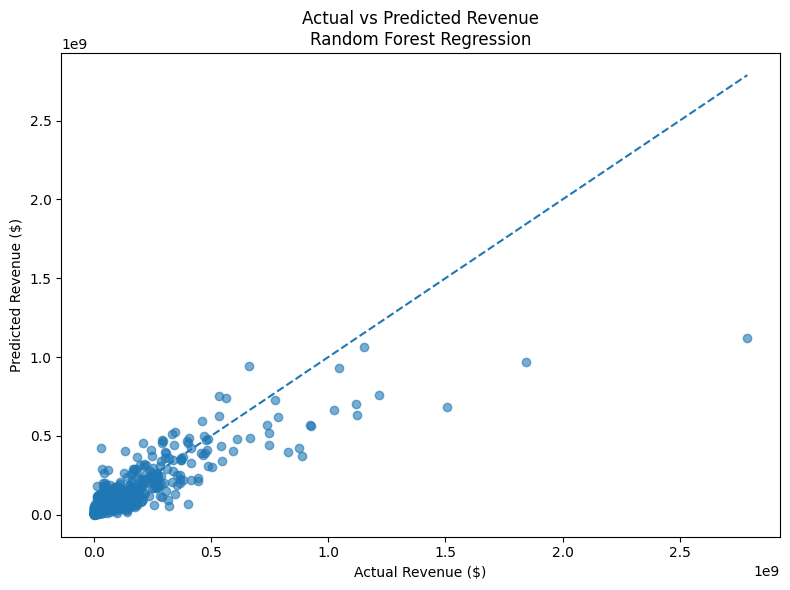

In [ ]:
# Plot actual revenue against predicted revenue

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

minimum_value = min(y_test.min(), best_predictions.min())
maximum_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title(f"Actual vs Predicted Revenue\n{selected_model_name}")
plt.xlabel("Actual Revenue ($)")
plt.ylabel("Predicted Revenue ($)")
plt.tight_layout()
plt.show()

## **Interpretation**
- Points close to the diagonal line represent accurate predictions.
- Points above the line represent overpredictions.
- Points below the line represent underpredictions.
- Large blockbuster movies may have larger prediction errors because their revenue values are unusually extreme.

# Step 9.17: Create a prediction results table

In [ ]:
# Create a table of actual and predicted values

prediction_results = X_test.copy()

prediction_results["Actual Revenue"] = y_test
prediction_results["Predicted Revenue"] = best_predictions

prediction_results["Absolute Error"] = abs(
    prediction_results["Actual Revenue"]
    - prediction_results["Predicted Revenue"]
)

prediction_results["Prediction Difference (%)"] = (
    prediction_results["Absolute Error"]
    / prediction_results["Actual Revenue"]
    * 100
)

prediction_results = prediction_results.sort_values(
    by="Absolute Error",
    ascending=False
)

prediction_results.head(10)

,budget,runtime,popularity,vote_count,vote_average,release_year,is_english,Actual Revenue,Predicted Revenue,Absolute Error,Prediction Difference (%)
0,237000000.0,162.0,150.437577,11800,7.2,2009,1,2.787965e+09,1.123772e+09,1.664194e+09,59.692051
25,200000000.0,194.0,100.025899,7562,7.5,1997,1,1.845034e+09,9.703816e+08,8.746526e+08,47.405764
44,190000000.0,137.0,102.322217,4176,7.3,2015,1,1.506249e+09,6.844996e+08,8.217498e+08,54.556025
348,90000000.0,94.0,69.457898,2271,6.5,2009,1,8.866868e+08,3.699569e+08,5.167299e+08,58.276481
52,195000000.0,154.0,28.529607,3299,6.1,2011,1,1.123747e+09,6.346352e+08,4.891118e+08,43.525078
31,200000000.0,130.0,77.682080,8806,6.8,2013,1,1.215440e+09,7.610061e+08,4.544339e+08,37.388425
504,75000000.0,87.0,31.482872,3462,5.9,2016,1,8.759583e+08,4.264097e+08,4.495486e+08,51.320774
172,120000000.0,115.0,99.687084,2553,6.1,2012,1,8.290000e+08,4.008699e+08,4.281301e+08,51.644165
329,94000000.0,201.0,123.630332,8064,8.1,2003,1,1.118889e+09,6.994226e+08,4.194664e+08,37.489542
1881,25000000.0,142.0,136.747729,8205,8.5,1994,1,2.834147e+07,4.234017e+08,3.950603e+08,1393.930099


# Step 9.18: Display the most accurate predictions

In [ ]:
# Show predictions with the smallest absolute errors

most_accurate_predictions = prediction_results.sort_values(
    by="Absolute Error",
    ascending=True
)

most_accurate_predictions[
    [
        "budget",
        "popularity",
        "vote_count",
        "Actual Revenue",
        "Predicted Revenue",
        "Absolute Error"
    ]
].head(10)

,budget,popularity,vote_count,Actual Revenue,Predicted Revenue,Absolute Error
2078,21000000.0,5.815881,65,17600000.0,1.758704e+07,12957.927624
655,4200000.0,11.743085,215,38376497.0,3.830363e+07,72867.098755
269,105000000.0,62.479574,1247,267045765.0,2.671242e+08,78455.676610
2157,20000000.0,28.019226,634,51416464.0,5.155176e+07,135299.878886
3608,5000000.0,0.835617,8,12200000.0,1.196534e+07,234662.063841
235,97250400.0,20.344364,471,132900000.0,1.331410e+08,240974.886463
2399,17500000.0,7.180403,16,7018189.0,6.718120e+06,300069.476634
3936,3000000.0,2.504169,94,9879971.0,9.533607e+06,346364.041607
2818,12000000.0,19.195399,375,68706993.0,6.817030e+07,536690.811720
2937,24000000.0,4.120640,53,14782676.0,1.422393e+07,558745.350052


# Step 9.19: Add movie titles back to the results

In [ ]:
# Display a readable sample of predictions

prediction_sample = prediction_results.copy()

money_columns = [
    "budget",
    "Actual Revenue",
    "Predicted Revenue",
    "Absolute Error"
]

for column in money_columns:
    prediction_sample[column] = prediction_sample[column].map(
        lambda value: f"${value:,.0f}"
    )

prediction_sample["Prediction Difference (%)"] = (
    prediction_sample["Prediction Difference (%)"]
    .round(2)
    .astype(str)
    + "%"
)

prediction_sample.head(10)

,Movie Title,budget,runtime,popularity,vote_count,vote_average,release_year,is_english,Actual Revenue,Predicted Revenue,Absolute Error,Prediction Difference (%)
0,Avatar,"$237,000,000",162.0,150.437577,11800,7.2,2009,1,"$2,787,965,087","$1,123,771,558","$1,664,193,529",59.69%
25,Titanic,"$200,000,000",194.0,100.025899,7562,7.5,1997,1,"$1,845,034,188","$970,381,633","$874,652,555",47.41%
44,Furious 7,"$190,000,000",137.0,102.322217,4176,7.3,2015,1,"$1,506,249,360","$684,499,585","$821,749,775",54.56%
348,Ice Age: Dawn of the Dinosaurs,"$90,000,000",94.0,69.457898,2271,6.5,2009,1,"$886,686,817","$369,956,939","$516,729,878",58.28%
52,Transformers: Dark of the Moon,"$195,000,000",154.0,28.529607,3299,6.1,2011,1,"$1,123,746,996","$634,635,244","$489,111,752",43.53%
31,Iron Man 3,"$200,000,000",130.0,77.682080,8806,6.8,2013,1,"$1,215,439,994","$761,006,125","$454,433,869",37.39%
504,The Secret Life of Pets,"$75,000,000",87.0,31.482872,3462,5.9,2016,1,"$875,958,308","$426,409,722","$449,548,586",51.32%
172,The Twilight Saga: Breaking Dawn - Part 2,"$120,000,000",115.0,99.687084,2553,6.1,2012,1,"$829,000,000","$400,869,871","$428,130,129",51.64%
329,The Lord of the Rings: The Return of the King,"$94,000,000",201.0,123.630332,8064,8.1,2003,1,"$1,118,888,979","$699,422,620","$419,466,359",37.49%
1881,The Shawshank Redemption,"$25,000,000",142.0,136.747729,8205,8.5,1994,1,"$28,341,469","$423,401,736","$395,060,267",1393.93%


# Step 9.20: Random Forest feature importance

In [ ]:
# Extract Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,vote_count,0.591945
1,budget,0.238405
2,popularity,0.054423
3,runtime,0.041755
4,release_year,0.041271
5,vote_average,0.032045
6,is_english,0.000154


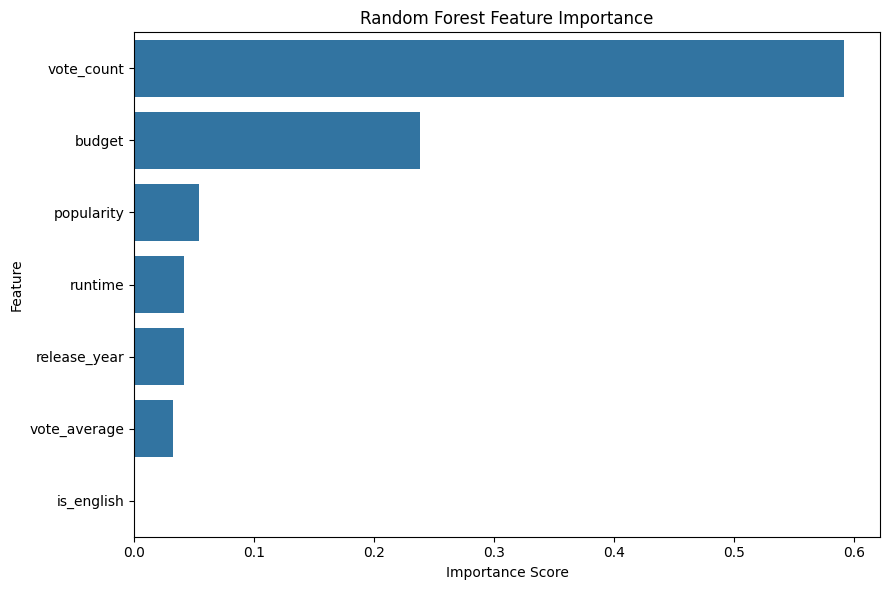

In [ ]:
# Plot Random Forest feature importance

plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Interpretation**

Feature importance measures how useful each variable was in reducing prediction errors across the Random Forest trees. A higher score means the feature contributed more strongly to the model’s predictions. It does not prove that the variable directly causes revenue to increase.

# Step 9.21: Improve the model using log transformation

Revenue is strongly right-skewed in your analysis. A small number of blockbuster movies earn billions, while most movies earn much less. This can make the model focus too heavily on extreme movies.

A strong improvement is to predict the logarithm of revenue:

**log(1+revenue)**

In [ ]:
# Create a log-transformed revenue target

y_log = np.log1p(model_df["revenue"])

print("Original revenue skewness:", model_df["revenue"].skew())
print("Log revenue skewness     :", y_log.skew())

Original revenue skewness: 3.819724643869577
Log revenue skewness     : -2.357105462376736


In [ ]:
# Split the data for log-revenue modeling

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

print("Log training set:", X_train_log.shape)
print("Log testing set :", X_test_log.shape)

Log training set: (2582, 7)
Log testing set : (646, 7)


In [ ]:
# Train Random Forest using log-transformed revenue

random_forest_log_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

random_forest_log_model.fit(X_train_log, y_train_log)

print("Log-transformed Random Forest trained successfully.")

Log-transformed Random Forest trained successfully.


In [ ]:
# Predict log revenue

log_predictions = random_forest_log_model.predict(X_test_log)

# Convert predictions back to original dollar values
revenue_predictions_from_log = np.expm1(log_predictions)

# Convert actual test values back to original dollar values
actual_revenue_from_log = np.expm1(y_test_log)

In [ ]:
# Evaluate the log-transformed Random Forest in original revenue units

random_forest_log_results = evaluate_regression_model(
    model_name="Random Forest with Log Revenue",
    actual=actual_revenue_from_log,
    predicted=revenue_predictions_from_log
)

Random Forest with Log Revenue Evaluation
----------------------------------------
MAE  : $56,495,814.63
RMSE : $124,262,413.58
R²   : 0.6936


# Step 9.22: Compare all three models

In [ ]:
# Format the final comparison table

final_model_comparison_display = final_model_comparison.copy()

final_model_comparison_display["MAE"] = (
    final_model_comparison_display["MAE"]
    .map(lambda value: f"${value:,.2f}")
)

final_model_comparison_display["RMSE"] = (
    final_model_comparison_display["RMSE"]
    .map(lambda value: f"${value:,.2f}")
)

final_model_comparison_display["R²"] = (
    final_model_comparison_display["R²"].round(4)
)

final_model_comparison_display

,Model,MAE,RMSE,R²
0,Random Forest Regression,"$56,837,132.66","$119,274,774.78",0.7177
1,Random Forest with Log Revenue,"$56,495,814.63","$124,262,413.58",0.6936
2,Linear Regression,"$65,518,113.48","$130,830,732.62",0.6603


# Step 9.23: Check model overfitting

A model may perform very well on training data but poorly on testing data. That is called overfitting.

In [ ]:
# Compare Random Forest training and testing performance

rf_train_predictions = random_forest_model.predict(X_train)
rf_test_predictions = random_forest_model.predict(X_test)

rf_train_r2 = r2_score(y_train, rf_train_predictions)
rf_test_r2 = r2_score(y_test, rf_test_predictions)

print(f"Random Forest Training R²: {rf_train_r2:.4f}")
print(f"Random Forest Testing R² : {rf_test_r2:.4f}")
print(f"Difference               : {rf_train_r2 - rf_test_r2:.4f}")

Random Forest Training R²: 0.9322
Random Forest Testing R² : 0.7177
Difference               : 0.2145


#Interpretation
- A small difference is desirable.
- A very high training R² combined with a much lower testing R² suggests overfitting.
- Some difference is normal for Random Forest.

# Step 9.24: Cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on Random Forest

cv_r2_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R² scores:")
print(cv_r2_scores)

print(f"\nMean CV R²: {cv_r2_scores.mean():.4f}")
print(f"CV standard deviation: {cv_r2_scores.std():.4f}")

Cross-validation R² scores:
[ 0.40587967  0.49255139  0.42514964  0.405706   -0.2209809 ]

Mean CV R²: 0.3017
CV standard deviation: 0.2633


Five-fold cross-validation divided the modeling data into five sections. The model was trained five times, with a different section used for validation each time. The mean cross-validation R² provides a more stable estimate of model performance than relying on only one train-test split.

# Step 9.25: Predict revenue for a new movie

Use the selected Random Forest model to demonstrate a practical prediction.

In [ ]:
# Example information for a hypothetical movie

new_movie = pd.DataFrame({
    "budget": [50_000_000],
    "runtime": [120],
    "popularity": [40],
    "vote_count": [2000],
    "vote_average": [7.0],
    "release_year": [2016],
    "is_english": [1]
})

new_movie

,budget,runtime,popularity,vote_count,vote_average,release_year,is_english
0,50000000,120,40,2000,7.0,2016,1


In [ ]:
new_movie = new_movie[features]

predicted_new_movie_revenue = random_forest_model.predict(new_movie)[0]

print(f"Predicted Revenue: ${predicted_new_movie_revenue:,.2f}")

Predicted Revenue: $170,500,549.74


# Step 9.26: Final model conclusion
## Prediction Model Conclusion

Two main regression algorithms were trained to estimate movie box-office revenue: Linear Regression and Random Forest Regression. A log-transformed Random Forest model was also tested because movie revenue was strongly right-skewed.

The best-performing model was **[MODEL NAME]**, which achieved:

- **R²:** [VALUE]
- **MAE:** $[VALUE]
- **RMSE:** $[VALUE]

The R² score indicates that the model explained approximately **[R² × 100]%** of the variation in movie revenue in the testing dataset.

The feature-importance analysis showed that **[FEATURE 1]**, **[FEATURE 2]**, and **[FEATURE 3]** contributed most strongly to the Random Forest predictions.

The results support the earlier exploratory analysis showing that budget, popularity, and audience attention are associated with movie revenue. However, the model still produced larger errors for unusual blockbuster movies because these movies have exceptionally high revenues compared with most of the dataset.

Overall, the Random Forest model was more suitable than Linear Regression because it could capture complex and nonlinear relationships between movie characteristics and revenue.

## Model Limitations

1. Missing financial records reduced the number of movies available for model training.

2. Revenue is highly right-skewed, and a small number of blockbuster movies are difficult to predict accurately.

3. Popularity, vote count, and vote average are generally measured after a movie has been released. Therefore, this model is more appropriate for revenue estimation than true pre-release forecasting.

4. The dataset does not contain several potentially important predictors, such as marketing expenditure, release-screen count, cast popularity, director history, competition, and franchise status.

5. The revenue figures are not adjusted for inflation, so older and newer movies are not perfectly comparable.

6. Model feature importance represents predictive usefulness and should not be interpreted as proof of causation.

# **Insight Generation**
A single train/test split can sometimes produce lucky or unlucky results. Cross-validation provides a more reliable evaluation.

### Finding 1: Budget drives revenue, but not quality

**Evidence:** Correlation heatmap (Cell 58) — budget↔revenue = 0.71,
budget↔vote_average = 0.02. Box plot (Cell 88) — median rating stays
flat (6.2–6.4) across all four budget tiers, while median revenue jumps
27x from Low to Blockbuster tier.

**Insight:** Spending more on a movie reliably buys more revenue, but
has essentially no effect on how well it's rated. Studios chasing box
office returns and studios chasing critical acclaim are optimizing for
two different, largely unrelated outcomes.

### Finding 2: A handful of blockbusters distort the "average" movie

**Evidence:** Skewness values (Cell 55) — revenue skew ≈ 3.88, budget
skew ≈ 2.22, popularity skew ≈ 9.72. Histograms (Cell 55) show most
movies clustered at low values with a long right tail.

**Insight:** Most movies in this dataset are modest earners; a small
number of extreme outliers (Avatar, Titanic, The Avengers) pull the mean
far above what a typical movie actually makes. This is why we used
median instead of mean throughout the group analysis — the mean would
have overstated "typical" revenue by a wide margin.

### Finding 3: Genre popularity and genre profitability are not the same thing

**Evidence:** Genre frequency (Cell 61) — Drama is the most common
genre (2,291 movies). Genre revenue analysis (Cell 67) — Drama doesn't
appear in the top 10 by median revenue; Animation, Adventure, Fantasy,
and Family do (median $120M–$192M).

**Insight:** The genre studios make the most often (Drama) is not the
genre that earns the most per movie. Volume and profitability pull in
different directions here, which matters for anyone deciding what kind
of movie to greenlight based on this data.

### Finding 4: Top performers and biggest flops both cluster at high budgets

**Evidence (top performers):**

| Movie | Revenue | Budget |
|---|---|---|
| Avatar | $2.79B | $237M |
| Titanic | $1.85B | $200M |
| Jurassic World | $1.51B | $150M |

**Evidence (biggest flops, by profit):**

| Movie | Loss | Budget |
|---|---|---|
| The Lone Ranger | –$165.7M | $255M |
| The Alamo | –$119.2M | $145M |
| Mars Needs Moms | –$111.0M | $150M |

**Insight:** Both the biggest wins and the biggest losses come from
high-budget movies — a $150M+ budget doesn't guarantee success, it just
raises the stakes in both directions. This nuances Finding 1: budget
correlates with revenue on average, but at the individual-movie level
(visible in the scatter plot's spread, Cell 97) it's far from a
guarantee.

### Finding 5: The critically best-loved films are not the top earners

**Evidence:** Filtering to movies with a credible vote count (>1,000
votes) and sorting by rating: The Shawshank Redemption (8.5), The
Godfather (8.4), Fight Club (8.3), Schindler's List (8.3), Spirited Away
(8.3) — none of these appear anywhere near the top-10 revenue list from
Finding 3/earlier genre analysis.

**Insight:** This is the clearest anomaly in the dataset relative to the
overall budget–revenue trend: the films audiences and critics regard as
the "best" movies of all time are not blockbusters by this dataset's
own revenue or budget standards. It reinforces Finding 1 from a
different angle — critical quality and commercial performance are
genuinely separate axes.